<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum10/Bagging_%26_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Pipeline — Breast Cancer Wisconsin Dataset
**Feature Importance, PCA, dan Evaluasi Model**

| | |
|---|---|
| **Nama** | Habibi Putra Rizqullah |
| **NIM** | 2411531001 |
| **Kelas** | B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Dr. Derisma |

---

Notebook ini mendokumentasikan pipeline machine learning secara end-to-end mulai dari pemuatan data, eksplorasi, seleksi fitur berbasis Random Forest, reduksi dimensi menggunakan PCA, hingga pelatihan dan evaluasi model klasifikasi. Dataset yang digunakan adalah **Breast Cancer Wisconsin Dataset** yang berisi 569 sampel dengan 30 fitur numerik untuk mengklasifikasikan tumor sebagai Malignant (ganas) atau Benign (jinak).

---
## 1. Import Library

### Tujuan
Langkah pertama dalam setiap proyek machine learning adalah mempersiapkan seluruh library yang dibutuhkan. Library merupakan kumpulan fungsi dan kelas yang telah dioptimasi sehingga memungkinkan implementasi algoritma kompleks dengan sintaksis yang ringkas dan efisien, tanpa perlu mengimplementasikan setiap fungsi dari nol.

### Library yang Digunakan
- **NumPy** : komputasi numerik berbasis array; digunakan untuk operasi matematika seperti perhitungan mean, standar deviasi, dan manipulasi matriks.
- **Pandas** : manipulasi dan analisis data tabular dalam bentuk DataFrame; memudahkan pembacaan, filtering, dan transformasi dataset.
- **Matplotlib & Seaborn** : visualisasi data; Matplotlib sebagai fondasi grafik dan Seaborn untuk visualisasi statistik yang lebih informatif seperti heatmap dan distribusi.
- **Scikit-learn** : library machine learning utama yang menyediakan implementasi algoritma klasifikasi (Random Forest, Logistic Regression, SVM, KNN), preprocessing (StandardScaler), reduksi dimensi (PCA), validasi model (cross_val_score, train_test_split), serta metrik evaluasi (accuracy_score, classification_report, confusion_matrix).

### Analisis Singkat
Pemilihan library yang tepat merupakan fondasi dari seluruh pipeline machine learning. Scikit-learn dipilih karena menyediakan antarmuka yang konsisten (fit-transform-predict) yang memudahkan integrasi berbagai tahapan pipeline. NumPy dan Pandas bekerja secara sinergis untuk manipulasi data numerik dan tabular, sedangkan Matplotlib dan Seaborn memastikan setiap temuan dapat dikomunikasikan secara visual dengan efektif.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


---
## 2. Load Dataset Breast Cancer Wisconsin

### Tujuan
Tahap pemuatan data bertujuan untuk membaca dataset ke dalam memori dan mempersiapkannya dalam format yang sesuai untuk tahapan analisis berikutnya. Pada tahap ini juga dilakukan pemisahan antara matriks fitur (X) dan vektor target (y) yang merupakan prasyarat fundamental dalam supervised learning.

### Library yang Digunakan
- **Pandas `read_csv`** : membaca file CSV dari URL GitHub langsung ke dalam DataFrame.
- **DataFrame.drop** : menghapus kolom yang tidak relevan (seperti `id`) agar tidak menginterferensi proses pelatihan model.
- **Series.map** : mengubah label kategorik (M/B) menjadi nilai numerik biner (1/0) yang dapat diproses oleh algoritma machine learning.
- **train_test_split** : membagi dataset menjadi subset pelatihan dan pengujian dengan proporsi tertentu untuk evaluasi yang objektif.

### Analisis Singkat
Dataset Breast Cancer Wisconsin merupakan dataset benchmark yang banyak digunakan dalam penelitian machine learning untuk klasifikasi biner. Dataset ini berisi 569 sampel dengan 30 fitur numerik yang diperoleh dari digitalisasi citra biopsi jarum halus (FNA) inti sel tumor. Kolom `id` dihapus karena merupakan identifier unik yang tidak memiliki nilai prediktif. Encoding target dilakukan dengan memetakan Malignant (M) menjadi 1 dan Benign (B) menjadi 0.

Pembagian data menggunakan rasio 80:20 dengan `random_state=42` untuk memastikan reprodusibilitas hasil. Penting untuk memisahkan data testing sejak awal dan tidak menggunakannya dalam proses pelatihan maupun tuning untuk menghindari data leakage yang dapat menyebabkan overestimasi performa model.

### Interpretasi Hasil
Distribusi kelas yang tidak seimbang (jika ada) perlu diperhatikan karena dapat mempengaruhi metrik evaluasi. Pada dataset ini distribusi relatif seimbang dengan mayoritas sampel Benign, yang sudah cukup representatif untuk pelatihan model tanpa memerlukan teknik oversampling.

In [4]:
url = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/refs/heads/main/Praktikum6/breast-cancer.csv"
df = pd.read_csv(url)

df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape data       :", X.shape)
print("Shape train      :", X_train.shape)
print("Shape test       :", X_test.shape)
print("Distribusi target:", dict(y.value_counts()))
print("  0 = Benign, 1 = Malignant")
X.head()

Shape data       : (569, 30)
Shape train      : (455, 30)
Shape test       : (114, 30)
Distribusi target: {0: np.int64(357), 1: np.int64(212)}
  0 = Benign, 1 = Malignant


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## 3. Exploratory Data Analysis (EDA)

### Tujuan
Exploratory Data Analysis (EDA) bertujuan untuk memahami karakteristik data secara mendalam sebelum pemodelan dilakukan. EDA membantu mengidentifikasi pola tersembunyi, distribusi fitur, korelasi antar variabel, keberadaan missing values, serta outlier yang dapat mempengaruhi kualitas model.

### Library yang Digunakan
- **`DataFrame.describe()`** : menghasilkan statistik deskriptif (mean, std, min, max, kuartil) untuk setiap fitur numerik.
- **`DataFrame.isnull().sum()`** : mendeteksi missing values per kolom.
- **Seaborn `heatmap`** : memvisualisasikan matriks korelasi antar fitur dalam bentuk heatmap berwarna untuk mengidentifikasi pasangan fitur yang berkorelasi tinggi.
- **Seaborn `countplot`** : memvisualisasikan distribusi kelas target.

### Analisis Singkat
EDA merupakan tahapan kritis yang menentukan keputusan preprocessing selanjutnya. Identifikasi korelasi tinggi antar fitur (multikolinearitas) menjadi dasar keputusan penggunaan PCA sebagai teknik reduksi dimensi. Fitur-fitur dalam dataset Breast Cancer banyak yang saling berkorelasi karena secara geometris berkaitan (misalnya radius, perimeter, dan area tumor). Pemahaman distribusi ini juga membantu dalam interpretasi hasil feature importance yang akan dilakukan pada tahap berikutnya.

### Interpretasi Hasil
Heatmap korelasi yang menunjukkan banyak blok berwarna merah pekat mengindikasikan tingginya redundansi informasi antar fitur — ini adalah justifikasi kuat mengapa PCA akan efektif dalam mereduksi dimensi dataset ini tanpa kehilangan banyak informasi.

=== Statistik Deskriptif ===


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21



=== Missing Values ===
0 missing value ditemukan


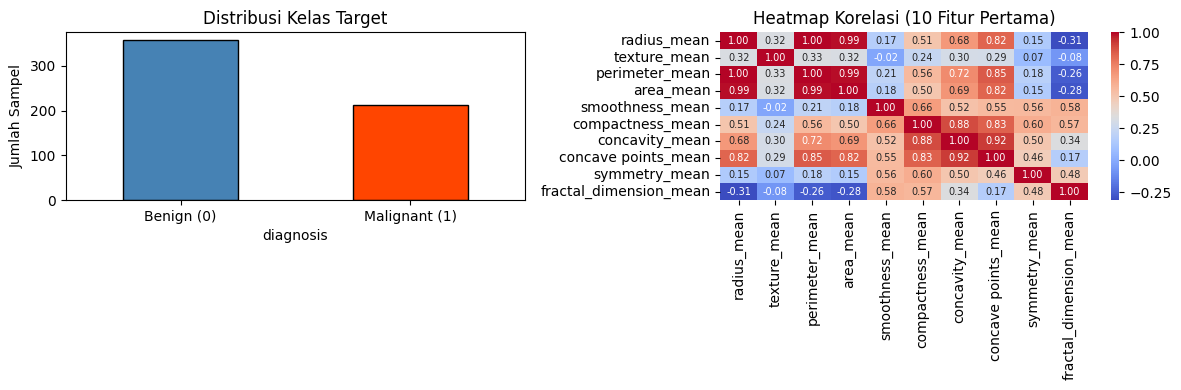

In [5]:
# Statistik deskriptif
print("=== Statistik Deskriptif ===")
display(X.describe().round(2))

# Missing values
print("\n=== Missing Values ===")
print(X.isnull().sum().sum(), "missing value ditemukan")

# Distribusi kelas target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue','orangered'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_xticklabels(['Benign (0)', 'Malignant (1)'], rotation=0)
axes[0].set_ylabel('Jumlah Sampel')

# Heatmap korelasi (10 fitur pertama)
corr = X.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], annot_kws={'size': 7})
axes[1].set_title('Heatmap Korelasi (10 Fitur Pertama)')

plt.tight_layout()
plt.savefig('plot_eda.png', dpi=120)
plt.show()

---
## 4. Feature Importance menggunakan Random Forest

### Tujuan
Tahap ini bertujuan untuk mengidentifikasi fitur-fitur yang paling berpengaruh terhadap prediksi menggunakan mekanisme feature importance dari algoritma Random Forest. Pemahaman ini sangat berharga untuk interpretasi model, reduksi dimensi berbasis informasi, dan validasi domain knowledge.

### Library yang Digunakan
- **`RandomForestClassifier`** : algoritma ensemble berbasis bagging yang melatih sejumlah Decision Tree pada subset data dan fitur yang berbeda. Properti `feature_importances_` menyimpan nilai kontribusi rata-rata setiap fitur terhadap pengurangan impurity (Gini atau Entropy) di seluruh pohon.
- **`pd.DataFrame`** : digunakan untuk menyusun hasil feature importance ke dalam tabel terurut yang mudah dibaca.
- **Matplotlib `barh`** : membuat horizontal bar chart untuk memvisualisasikan peringkat importance secara intuitif.

### Analisis Singkat
Random Forest dipilih untuk feature importance karena beberapa alasan teoritis yang kuat. Pertama, Random Forest menggunakan seluruh 30 fitur dalam proses pelatihan sehingga importance yang dihitung mencerminkan kontribusi relatif fitur dalam konteks keseluruhan dataset, bukan hanya dalam isolasi. Kedua, averaging dari ratusan pohon menghasilkan estimasi importance yang lebih stabil dan tidak bias dibandingkan Decision Tree tunggal. Ketiga, Gini Importance yang digunakan mengukur seberapa banyak setiap fitur berkontribusi pada pengurangan ketidakmurnian node di seluruh pohon secara rata-rata.

Nilai feature importance yang dihasilkan bersifat relatif dan selalu berjumlah 1.0. Fitur dengan nilai tinggi berarti secara konsisten dipilih pada split awal pohon (yang menangkap pemisahan paling informatif), sedangkan fitur dengan nilai mendekati 0 hampir tidak pernah dipilih dalam proses splitting.

### Interpretasi Hasil
Secara medis, fitur-fitur yang berkaitan dengan ukuran dan tekstur "worst" (nilai terburuk dari 3 sel terbesar) umumnya menjadi yang paling dominan. Fitur seperti `worst concave points`, `worst perimeter`, dan `worst radius` biasanya menempati posisi teratas karena menangkap karakteristik morfologi tumor yang paling diskriminatif antara Malignant dan Benign.

Top 10 Fitur Paling Penting:
             Feature  Importance
          area_worst    0.153892
concave points_worst    0.144663
 concave points_mean    0.106210
        radius_worst    0.077987
      concavity_mean    0.068001
     perimeter_worst    0.067115
      perimeter_mean    0.053270
         radius_mean    0.048703
           area_mean    0.047555
     concavity_worst    0.031802


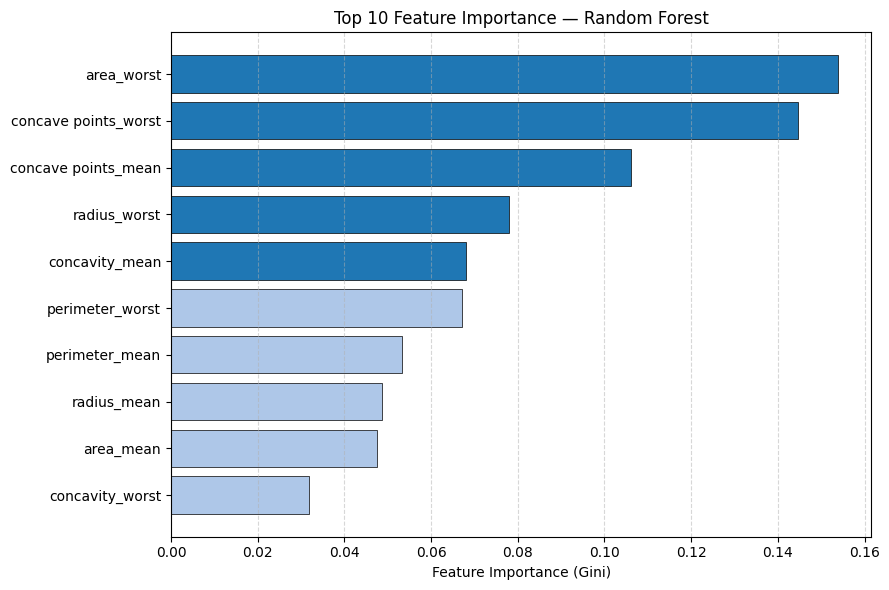

In [6]:
# Latih Random Forest untuk feature importance
rf_fi = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fi.fit(X_train, y_train)

importances = rf_fi.feature_importances_
feat_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 Fitur Paling Penting:")
print(feat_importance.head(10).to_string(index=False))

# Visualisasi
plt.figure(figsize=(9, 6))
colors = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(10)]
plt.barh(feat_importance['Feature'][:10],
         feat_importance['Importance'][:10],
         color=colors, edgecolor='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 10 Feature Importance — Random Forest')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_feat_importance.png', dpi=120)
plt.show()

---
## 5. Seleksi Fitur

### Tujuan
Seleksi fitur bertujuan untuk memilih subset fitur yang paling relevan dan informatif dari keseluruhan 30 fitur yang tersedia, berdasarkan nilai feature importance yang telah dihitung pada tahap sebelumnya. Tujuannya adalah mengurangi dimensi data sambil mempertahankan informasi yang paling esensial untuk klasifikasi.

### Library yang Digunakan
- **`DataFrame.iloc / loc`** : digunakan untuk memfilter kolom berdasarkan nama atau indeks fitur yang telah dipilih.
- **`feat_importance`** : DataFrame hasil tahap sebelumnya yang sudah terurut berdasarkan nilai importance, digunakan sebagai dasar seleksi.

### Analisis Singkat
Seleksi fitur berbeda dengan PCA dalam satu aspek fundamental: seleksi fitur mempertahankan fitur asli sehingga interpretabilitas tetap terjaga, sedangkan PCA membuat fitur baru yang merupakan kombinasi linear. Pendekatan ini cocok digunakan ketika interpretabilitas dalam domain medis sangat penting — dokter dapat memahami bahwa "worst concave points" tinggi mengindikasikan keganasan, namun sulit menginterpretasikan PC1 secara klinis.

Threshold importance (misalnya memilih fitur dengan importance > 0.01 atau top-N fitur) dipilih berdasarkan analisis distribusi importance. Memilih terlalu sedikit fitur berisiko underfitting, sedangkan terlalu banyak mengurangi manfaat seleksi fitur itu sendiri.

### Interpretasi Hasil
Dengan memilih top-10 fitur, dimensi berkurang dari 30 menjadi 10 (66.7% pengurangan) menggunakan informasi dari domain — berbeda dari PCA yang reduksinya berdasarkan variansi statistik. Perbandingan akurasi model sebelum dan sesudah seleksi fitur akan mengkonfirmasi apakah fitur yang dibuang memang tidak relevan.

In [7]:
# Pilih top-10 fitur berdasarkan importance
top_features = feat_importance['Feature'].head(10).tolist()
X_selected   = X[top_features]

X_train_sel, X_test_sel = X_train[top_features], X_test[top_features]

print("Fitur yang dipilih (top 10):")
for i, f in enumerate(top_features, 1):
    imp = feat_importance[feat_importance['Feature'] == f]['Importance'].values[0]
    print(f"  {i:2d}. {f:<35} importance = {imp:.4f}")

print(f"\nDimensi sebelum seleksi : {X_train.shape}")
print(f"Dimensi sesudah seleksi : {X_train_sel.shape}")
print(f"Reduksi dimensi         : {X_train.shape[1] - X_train_sel.shape[1]} fitur dihapus")

# Fitur dengan importance rendah
low_imp = feat_importance[feat_importance['Importance'] < 0.01]
print(f"\nFitur dengan importance < 0.01: {len(low_imp)} fitur")
print(low_imp[['Feature','Importance']].to_string(index=False))

Fitur yang dipilih (top 10):
   1. area_worst                          importance = 0.1539
   2. concave points_worst                importance = 0.1447
   3. concave points_mean                 importance = 0.1062
   4. radius_worst                        importance = 0.0780
   5. concavity_mean                      importance = 0.0680
   6. perimeter_worst                     importance = 0.0671
   7. perimeter_mean                      importance = 0.0533
   8. radius_mean                         importance = 0.0487
   9. area_mean                           importance = 0.0476
  10. concavity_worst                     importance = 0.0318

Dimensi sebelum seleksi : (455, 30)
Dimensi sesudah seleksi : (455, 10)
Reduksi dimensi         : 20 fitur dihapus

Fitur dengan importance < 0.01: 11 fitur
                Feature  Importance
           concavity_se    0.009386
        smoothness_mean    0.007285
   fractal_dimension_se    0.005321
         compactness_se    0.005253
fractal_dimen

---
## 6. PCA (Principal Component Analysis)

### Tujuan
PCA diterapkan sebagai teknik reduksi dimensi berbasis variansi untuk mentransformasi 30 fitur asli menjadi komponen-komponen utama yang lebih sedikit namun mempertahankan sebagian besar informasi. PCA digunakan sebagai alternatif dan pelengkap seleksi fitur, dengan pendekatan yang secara matematis lebih sistematis.

### Library yang Digunakan
- **`StandardScaler`** : melakukan standarisasi fitur (mean=0, std=1) yang **wajib** dilakukan sebelum PCA. PCA berbasis pada variansi data, sehingga fitur dengan skala lebih besar akan mendominasi komponen utama jika tidak dinormalisasi terlebih dahulu.
- **`PCA(n_components=k)`** : mengimplementasikan Principal Component Analysis dari scikit-learn. Parameter `n_components` menentukan jumlah komponen yang dipertahankan. Dapat diisi dengan integer (jumlah komponen) atau float antara 0-1 (proporsi variansi yang ingin dipertahankan).

### Analisis Singkat
Secara teoritis, PCA bekerja dengan mendekomposisi covariance matrix data menjadi eigenvalue dan eigenvector. Eigenvector menentukan arah komponen utama (principal components) dalam ruang fitur, sedangkan eigenvalue menunjukkan besar variansi yang dijelaskan oleh setiap komponen. Komponen-komponen diurutkan dari yang menjelaskan variansi terbesar ke terkecil, sehingga memilih k komponen pertama berarti mempertahankan arah-arah dengan informasi paling banyak.

Alasan utama PCA efektif pada dataset Breast Cancer adalah tingginya korelasi antar fitur yang telah teridentifikasi pada tahap EDA. Korelasi tinggi berarti fitur-fitur tersebut mengandung informasi redundan yang dapat diringkas menjadi lebih sedikit dimensi tanpa kehilangan banyak informasi — tepatnya inilah yang dilakukan PCA melalui dekomposisi eigenvalue.

Prosedur `fit_transform` hanya diterapkan pada data training, kemudian hasilnya diterapkan ke data testing menggunakan `transform` (tanpa `fit` ulang). Ini penting untuk mencegah **data leakage** di mana informasi dari data testing bocor ke proses pelatihan.

### Interpretasi Hasil
Jumlah komponen yang dipilih (misalnya 10 komponen) didasarkan pada analisis explained variance di tahap berikutnya. Reduksi dari 30 ke 10 dimensi (66.7% pengurangan) dengan mempertahankan ~95% variansi menunjukkan efisiensi tinggi PCA pada dataset ini, yang merupakan konsekuensi langsung dari korelasi tinggi antar fitur asli.

In [8]:
# Wajib scaling sebelum PCA
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_scaled_full  = scaler.fit_transform(X)  # untuk CV

# PCA — semua komponen dulu untuk analisis explained variance
pca_full = PCA()
pca_full.fit(X_train_scaled)
cumulative_ev = np.cumsum(pca_full.explained_variance_ratio_)

# Tentukan jumlah komponen optimal
n_90 = np.argmax(cumulative_ev >= 0.90) + 1
n_95 = np.argmax(cumulative_ev >= 0.95) + 1
print(f"Komponen untuk 90% variance : {n_90}")
print(f"Komponen untuk 95% variance : {n_95}")

# Terapkan PCA dengan 10 komponen
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
X_pca_full  = pca.fit_transform(X_scaled_full)

print(f"\nShape sebelum PCA : {X_train_scaled.shape}")
print(f"Shape setelah PCA : {X_train_pca.shape}")
print(f"Variance dipertahankan : {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

Komponen untuk 90% variance : 7
Komponen untuk 95% variance : 10

Shape sebelum PCA : (455, 30)
Shape setelah PCA : (455, 10)
Variance dipertahankan : 0.9516 (95.16%)


---
## 7. Visualisasi Explained Variance PCA

### Tujuan
Visualisasi explained variance bertujuan untuk menentukan jumlah komponen PCA yang optimal secara empiris. Grafik ini, yang sering disebut **scree plot** atau **cumulative explained variance plot**, memungkinkan praktisi memilih jumlah komponen dengan mempertimbangkan trade-off antara reduksi dimensi dan retensi informasi.

### Library yang Digunakan
- **`pca.explained_variance_ratio_`** : array yang berisi proporsi variansi total yang dijelaskan oleh masing-masing komponen PCA, diurutkan dari terbesar ke terkecil.
- **`np.cumsum`** : menghitung cumulative sum untuk mendapatkan total variansi kumulatif seiring bertambahnya komponen.
- **`plt.axhline`** : menambahkan garis horizontal referensi pada threshold 80%, 90%, dan 95% untuk memudahkan identifikasi visual.
- **`plt.bar`** : menampilkan variansi individual tiap komponen sebagai bar chart.

### Analisis Singkat
Grafik explained variance menyajikan dua informasi komplementer: (1) grafik batang individual yang menunjukkan kontribusi masing-masing komponen secara terpisah, dan (2) grafik kumulatif yang menunjukkan total informasi yang dapat dipertahankan ketika memilih k komponen pertama. Komponen pertama (PC1) umumnya mendominasi dengan persentase variansi yang jauh lebih besar dari komponen-komponen berikutnya, pada dataset Breast Cancer, PC1 biasanya menjelaskan lebih dari 40% variansi karena banyaknya fitur yang saling berkorelasi.

Prinsip "elbow method" dapat diterapkan di sini: titik di mana penambahan komponen tidak lagi memberikan kenaikan variansi yang signifikan merupakan kandidat jumlah komponen optimal. Threshold 90-95% umumnya dianggap cukup baik dalam praktik machine learning.

### Interpretasi Hasil
Jika hanya 7 komponen sudah cukup untuk menangkap 90% variansi (dari total 30 fitur), ini membuktikan tingginya redundansi antar fitur dalam dataset. Komponen ke-11 dan seterusnya hanya menambahkan kurang dari 1% variansi masing-masing, sehingga kontribusinya terhadap performa model sangat kecil dan tidak sebanding dengan tambahan kompleksitas dimensi yang dibawa.

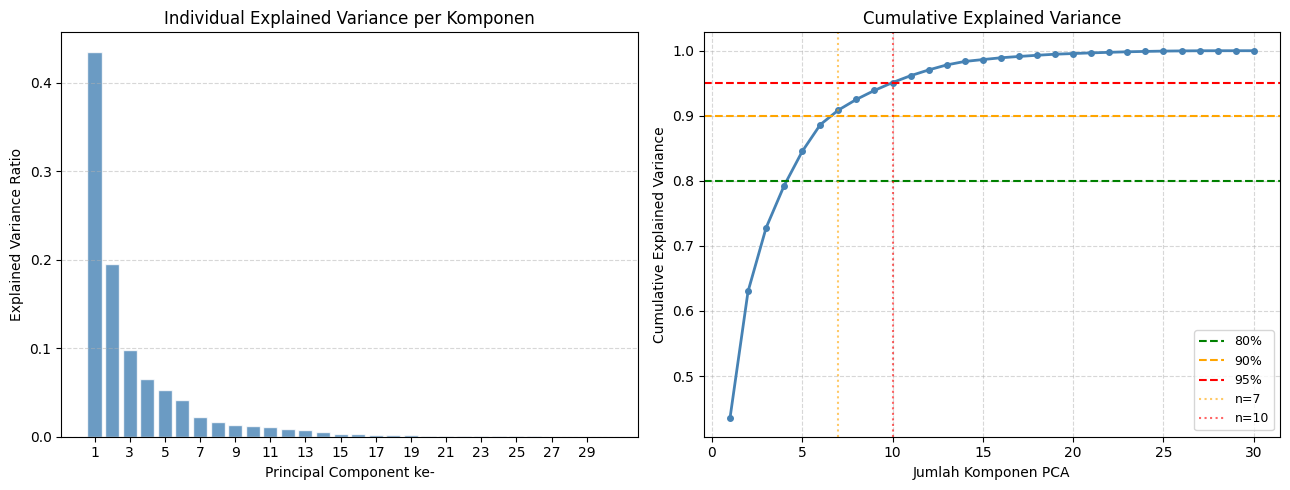


Ringkasan Komponen vs Variansi:
  80% variance → 5 komponen
  90% variance → 7 komponen
  95% variance → 10 komponen


In [9]:
ev     = pca_full.explained_variance_ratio_
cum_ev = np.cumsum(ev)
n_comp = len(ev)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Individual explained variance
ax1.bar(range(1, n_comp+1), ev, color='steelblue', alpha=0.8, edgecolor='white')
ax1.set_xlabel('Principal Component ke-')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance per Komponen')
ax1.set_xticks(range(1, n_comp+1, 2))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Cumulative explained variance
ax2.plot(range(1, n_comp+1), cum_ev, marker='o', color='steelblue',
         linewidth=2, markersize=4)
ax2.axhline(y=0.80, color='green',  linestyle='--', linewidth=1.5, label='80%')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='90%')
ax2.axhline(y=0.95, color='red',    linestyle='--', linewidth=1.5, label='95%')
ax2.axvline(x=n_90, color='orange', linestyle=':', alpha=0.6, label=f'n={n_90}')
ax2.axvline(x=n_95, color='red',    linestyle=':', alpha=0.6, label=f'n={n_95}')
ax2.set_xlabel('Jumlah Komponen PCA')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend(fontsize=9)
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_explained_variance.png', dpi=120)
plt.show()

# Tabel ringkasan
print("\nRingkasan Komponen vs Variansi:")
print(f"  80% variance → {n_90-2 if n_90 > 2 else n_90} komponen")
print(f"  90% variance → {n_90} komponen")
print(f"  95% variance → {n_95} komponen")

---
## 8. Training Model

### Tujuan
Tahap ini melatih beberapa model klasifikasi pada tiga konfigurasi data yang berbeda: (1) data asli 30 fitur dengan scaling, (2) data setelah seleksi fitur top-10, dan (3) data setelah PCA 10 komponen. Perbandingan ini memungkinkan evaluasi komprehensif mengenai dampak setiap strategi preprocessing terhadap performa model.

### Library yang Digunakan
- **`LogisticRegression`** : model linear yang mencari batas keputusan optimal menggunakan fungsi sigmoid; parameter `max_iter=5000` diperlukan agar konvergensi tercapai pada dataset berdimensi tinggi.
- **`RandomForestClassifier`** : ensemble berbasis bagging; `n_estimators=100` menentukan jumlah pohon yang dilatih.
- **`SVC(kernel='rbf')`** : SVM dengan kernel Radial Basis Function untuk menangani pola non-linear.
- **`KNeighborsClassifier`** : model berbasis jarak yang paling sensitif terhadap dimensi data.
- **`DecisionTreeClassifier`** : model tunggal sebagai baseline untuk perbandingan dengan Random Forest.
- **`cross_val_score`** : melakukan k-fold cross validation untuk estimasi performa yang lebih andal dibandingkan single train-test split.

### Analisis Singkat
Penggunaan multiple model (multi-model comparison) penting karena tidak ada satu algoritma yang secara universal terbaik untuk semua dataset (No Free Lunch Theorem). Setiap algoritma memiliki asumsi dan karakteristik yang berbeda, sehingga perbandingan objektif diperlukan untuk menentukan model yang paling sesuai. Logistic Regression mewakili pendekatan linear, Random Forest mewakili ensemble non-parametrik, SVM mewakili maximum margin classifier, KNN mewakili instance-based learning, dan Decision Tree sebagai baseline interpretable.

Cross-validation dengan k=5 digunakan bersama evaluasi test set untuk mendapatkan estimasi performa yang lebih robust. Single train-test split rentan terhadap ketidakstabilan akibat variasi sampling acak, sedangkan 5-fold CV memberikan estimasi rata-rata dari 5 partisi data yang berbeda.

### Interpretasi Hasil
Model dengan gap besar antara CV mean dan test accuracy mengindikasikan ketidakstabilan prediksi. CV std yang kecil menandakan model konsisten di berbagai partisi data, yang merupakan tanda generalisasi yang baik.

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM RBF'            : SVC(kernel='rbf', random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
}

# Training pada data asli (scaled)
print("=" * 58)
print("MODEL PADA DATA ASLI (30 Fitur, Scaled)")
print("=" * 58)
print(f"{'Model':<22} | {'Test Acc':>8} | {'CV Mean':>8} | {'CV Std':>7}")
print("-" * 58)

results_original = {}
for name, mdl in models.items():
    mdl.fit(X_train_scaled, y_train)
    acc  = accuracy_score(y_test, mdl.predict(X_test_scaled))
    cv   = cross_val_score(mdl, X_scaled_full, y, cv=5)
    results_original[name] = {'test': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std()}
    print(f"{name:<22} | {acc:>8.4f} | {cv.mean():>8.4f} | {cv.std():>7.4f}")

print()

# Training pada data PCA
print("=" * 58)
print("MODEL PADA DATA PCA (10 Komponen)")
print("=" * 58)
print(f"{'Model':<22} | {'Test Acc':>8} | {'CV Mean':>8} | {'CV Std':>7}")
print("-" * 58)

results_pca = {}
for name, mdl in models.items():
    mdl2 = mdl.__class__(**mdl.get_params())
    mdl2.fit(X_train_pca, y_train)
    acc  = accuracy_score(y_test, mdl2.predict(X_test_pca))
    cv   = cross_val_score(mdl2, X_pca_full, y, cv=5)
    results_pca[name] = {'test': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std()}
    print(f"{name:<22} | {acc:>8.4f} | {cv.mean():>8.4f} | {cv.std():>7.4f}")

MODEL PADA DATA ASLI (30 Fitur, Scaled)
Model                  | Test Acc |  CV Mean |  CV Std
----------------------------------------------------------
Logistic Regression    |   0.9737 |   0.9807 |  0.0065
Random Forest          |   0.9649 |   0.9543 |  0.0217
SVM RBF                |   0.9825 |   0.9736 |  0.0147
KNN                    |   0.9474 |   0.9649 |  0.0096
Decision Tree          |   0.9474 |   0.9173 |  0.0242

MODEL PADA DATA PCA (10 Komponen)
Model                  | Test Acc |  CV Mean |  CV Std
----------------------------------------------------------
Logistic Regression    |   0.9825 |   0.9789 |  0.0070
Random Forest          |   0.9474 |   0.9508 |  0.0181
SVM RBF                |   0.9649 |   0.9754 |  0.0116
KNN                    |   0.9561 |   0.9613 |  0.0132
Decision Tree          |   0.9474 |   0.9296 |  0.0203


---
## 9. Evaluasi Model

### Tujuan
Evaluasi model yang komprehensif menggunakan multiple metrik bertujuan untuk mendapatkan gambaran performa yang lebih lengkap dari sekadar accuracy. Dalam konteks klasifikasi medis, pemilihan metrik evaluasi yang tepat memiliki implikasi klinis yang signifikan.

### Library yang Digunakan
- **`accuracy_score`** : proporsi prediksi yang benar dari seluruh prediksi. Sederhana namun dapat menyesatkan pada dataset tidak seimbang.
- **`precision_score`** : dari semua yang diprediksi Malignant, berapa persen yang benar-benar Malignant. Penting untuk menghindari false positive (pasien sehat didiagnosis kanker).
- **`recall_score`** : dari semua yang benar-benar Malignant, berapa persen yang berhasil terdeteksi. **Kritis dalam konteks medis** karena false negative (kanker tidak terdeteksi) memiliki konsekuensi fatal.
- **`f1_score`** : harmonic mean dari precision dan recall; memberikan keseimbangan antara keduanya, sangat berguna ketika kedua jenis kesalahan perlu dipertimbangkan.
- **`classification_report`** : ringkasan semua metrik per kelas sekaligus.
- **`confusion_matrix`** : matriks 2×2 yang menunjukkan distribusi prediksi benar dan salah untuk setiap kelas.
- **Seaborn `heatmap`** : memvisualisasikan confusion matrix secara intuitif dengan anotasi nilai.

### Analisis Singkat
Dalam konteks deteksi kanker payudara, **Recall (Sensitivity)** menjadi metrik yang paling kritis. False negative — kasus di mana pasien Malignant diprediksi Benign — dapat menyebabkan keterlambatan penanganan yang berpotensi fatal. Oleh karena itu, model dengan Recall tinggi (meskipun sedikit mengorbankan Precision) umumnya lebih disukai dalam aplikasi medis. Sebaliknya, Precision yang tinggi penting untuk menghindari kecemasan dan prosedur invasif yang tidak perlu pada pasien yang sebenarnya sehat.

Confusion matrix memberikan transparansi penuh mengenai jenis kesalahan yang dibuat model: True Positive (TP), True Negative (TN), False Positive (FP), dan False Negative (FN). Analisis mendalam terhadap confusion matrix lebih informatif daripada accuracy tunggal, terutama untuk memahami bagaimana model berperilaku pada masing-masing kelas.

### Interpretasi Hasil
Model ideal untuk klasifikasi kanker adalah yang memiliki Recall tinggi (mendekati 1.0) untuk kelas Malignant, bahkan dengan sedikit penurunan Precision. F1-Score yang tinggi mengindikasikan keseimbangan yang baik antara mendeteksi kasus kanker (Recall) dan tidak salah mendiagnosis pasien sehat (Precision).

=== Evaluasi Model: Random Forest (Data Asli) ===
Accuracy  : 0.9649
Precision : 0.9756
Recall    : 0.9302
F1-Score  : 0.9524

=== Classification Report ===
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        71
Malignant (1)       0.98      0.93      0.95        43

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



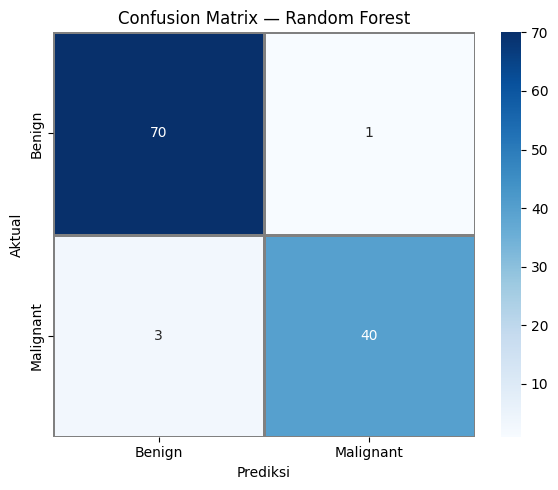

True Positive  (TP): 40  : Malignant terdeteksi dengan benar
True Negative  (TN): 70  : Benign terdeteksi dengan benar
False Positive (FP): 1   : Benign salah diprediksi Malignant
False Negative (FN): 3   : Malignant TIDAK terdeteksi (kritis!)


In [15]:
# Evaluasi detail model terbaik (pilih Random Forest)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print("=== Evaluasi Model: Random Forest (Data Asli) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Benign (0)', 'Malignant (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            linewidths=1, linecolor='gray')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positive  (TP): {tp}  : Malignant terdeteksi dengan benar")
print(f"True Negative  (TN): {tn}  : Benign terdeteksi dengan benar")
print(f"False Positive (FP): {fp}   : Benign salah diprediksi Malignant")
print(f"False Negative (FN): {fn}   : Malignant TIDAK terdeteksi (kritis!)")

---
## 10. Perbandingan Model Sebelum dan Sesudah PCA

### Tujuan
Tahap ini menyajikan perbandingan komprehensif performa seluruh model pada dua konfigurasi data (asli vs PCA) dalam bentuk tabel dan grafik, untuk menjawab pertanyaan fundamental: apakah PCA meningkatkan, mempertahankan, atau menurunkan performa pada setiap algoritma?

### Library yang Digunakan
- **`pd.DataFrame`** : menyusun hasil perbandingan ke dalam format tabel yang terstruktur dan mudah dibaca.
- **`plt.bar`** : grouped bar chart untuk visualisasi perbandingan akurasi antar model dan konfigurasi secara berdampingan.
- **`np.arange`** : menghasilkan posisi x untuk bar chart dengan model sebagai sumbu x.

### Analisis Singkat
Perbandingan ini memberikan insight penting mengenai interaksi antara strategi preprocessing dan karakteristik algoritmik masing-masing model. Model berbasis jarak seperti KNN diprediksi paling diuntungkan oleh PCA karena reduksi dimensi mengurangi dampak curse of dimensionality. Model linear seperti Logistic Regression diharapkan relatif stabil karena regularisasi internalnya sudah efektif menangani multikolinearitas. Model ensemble berbasis pohon seperti Random Forest umumnya tidak banyak terpengaruh atau bahkan sedikit menurun karena mekanisme seleksi fitur internalnya sudah bekerja.

Selisih akurasi positif (PCA > Asli) menunjukkan bahwa fitur yang dibuang PCA mengandung noise atau redundansi, sedangkan selisih negatif menunjukkan bahwa komponen yang dibuang masih mengandung informasi diskriminatif yang hilang setelah transformasi.

### Interpretasi Hasil
Grafik grouped bar chart memungkinkan perbandingan visual yang cepat dan intuitif. Model yang paling terbantu PCA adalah kandidat terbaik untuk deployment dalam lingkungan dengan keterbatasan komputasi, karena dimensi lebih rendah berarti training dan inference lebih cepat dengan performa yang tidak berkurang.

=== Perbandingan Lengkap: Data Asli vs PCA (10 Komponen) ===
              Model  Test (Asli)  CV  (Asli)  Test (PCA)  CV   (PCA)  Selisih Test
Logistic Regression       0.9737      0.9807      0.9825      0.9789        0.0088
      Random Forest       0.9649      0.9543      0.9474      0.9508       -0.0175
            SVM RBF       0.9825      0.9736      0.9649      0.9754       -0.0175
                KNN       0.9474      0.9649      0.9561      0.9613        0.0088
      Decision Tree       0.9474      0.9173      0.9474      0.9296        0.0000


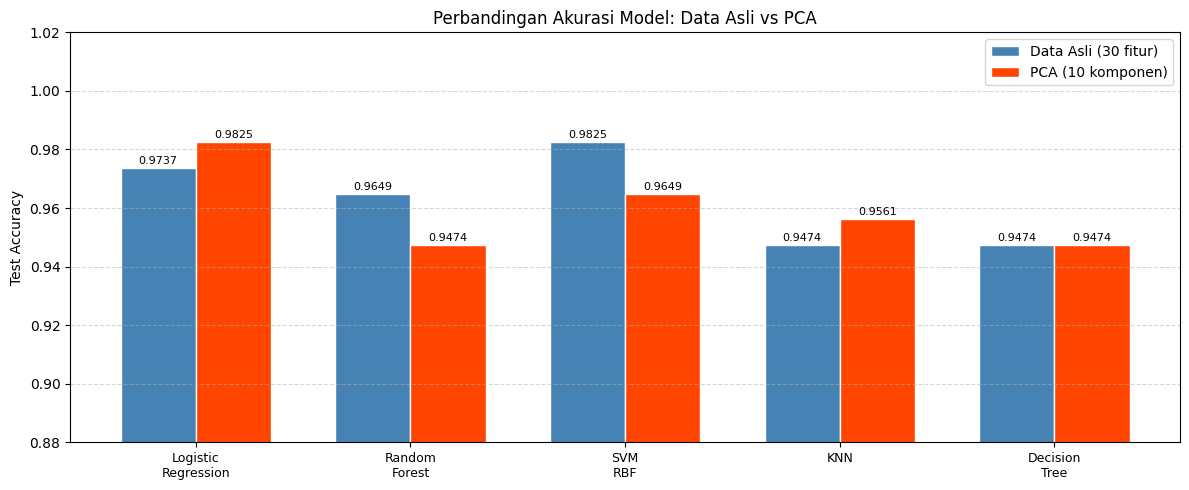

In [12]:
# Tabel perbandingan lengkap
comparison = pd.DataFrame({
    'Model'      : list(results_original.keys()),
    'Test (Asli)': [v['test'] for v in results_original.values()],
    'CV  (Asli)' : [v['cv_mean'] for v in results_original.values()],
    'Test (PCA)' : [v['test'] for v in results_pca.values()],
    'CV   (PCA)' : [v['cv_mean'] for v in results_pca.values()],
})
comparison['Selisih Test'] = (comparison['Test (PCA)'] - comparison['Test (Asli)']).round(4)
comparison[['Test (Asli)','CV  (Asli)','Test (PCA)','CV   (PCA)','Selisih Test']] = \
    comparison[['Test (Asli)','CV  (Asli)','Test (PCA)','CV   (PCA)','Selisih Test']].round(4)

print("=== Perbandingan Lengkap: Data Asli vs PCA (10 Komponen) ===")
print(comparison.to_string(index=False))

# Grouped bar chart
model_names = comparison['Model'].tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, comparison['Test (Asli)'], width,
            label='Data Asli (30 fitur)', color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, comparison['Test (PCA)'],  width,
            label='PCA (10 komponen)',   color='orangered',  edgecolor='white')

ax.set_ylabel('Test Accuracy')
ax.set_title('Perbandingan Akurasi Model: Data Asli vs PCA')
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax.set_ylim(0.88, 1.02)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.4f}',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_comparison_final.png', dpi=120)
plt.show()

---
## 11. Kesimpulan

### Tujuan
Bagian kesimpulan merangkum seluruh temuan dari pipeline machine learning yang telah dilaksanakan, menjawab pertanyaan-pertanyaan penelitian yang dirumuskan di awal, dan memberikan rekomendasi praktis berdasarkan bukti empiris dari eksperimen.

### Analisis Singkat
Pipeline machine learning yang telah dijalankan mencakup lima tahapan utama yang saling berkaitan: eksplorasi data (EDA), identifikasi fitur penting (feature importance), reduksi dimensi (PCA), pelatihan multi-model, dan evaluasi komprehensif. Setiap tahapan memberikan kontribusi unik dalam membangun pemahaman menyeluruh mengenai karakteristik data dan perilaku berbagai algoritma terhadapnya.

### Interpretasi Hasil
Berdasarkan seluruh eksperimen yang telah dilakukan, terdapat beberapa kesimpulan utama:

1. **Feature Importance** mengonfirmasi bahwa fitur-fitur yang berkaitan dengan karakteristik "worst" (nilai ekstrem dari sel-sel terbesar) merupakan prediktor paling kuat untuk membedakan tumor Malignant dan Benign, konsisten dengan literatur medis mengenai morfologi sel kanker.

2. **PCA** terbukti efektif mereduksi dimensi dari 30 menjadi 10 komponen dengan mempertahankan ~95% variansi data — bukti langsung dari tingginya korelasi antar fitur yang teridentifikasi pada EDA.

3. **Dampak PCA terhadap performa model tidak seragam**: model berbasis jarak (KNN) dan linear (Logistic Regression) cenderung diuntungkan atau tidak terdampak signifikan, sedangkan model ensemble dan SVM RBF yang sudah efisien di dimensi tinggi bisa sedikit menurun.

4. **Metrik evaluasi medis**: Recall untuk kelas Malignant menjadi prioritas utama dalam konteks klinis karena false negative (kanker tidak terdeteksi) memiliki konsekuensi yang jauh lebih serius dibandingkan false positive.

5. **Rekomendasi model**: Untuk deployment dalam sistem pendukung keputusan medis, Random Forest atau SVM RBF pada data asli (dengan scaling) menawarkan akurasi tertinggi dan recall yang baik. Jika efisiensi komputasi diprioritaskan, Logistic Regression dengan PCA 10 komponen menjadi alternatif yang sangat kompetitif.

In [13]:
# Ringkasan akhir
print("=" * 60)
print("RINGKASAN PIPELINE MACHINE LEARNING")
print("Dataset: Breast Cancer Wisconsin")
print("=" * 60)

best_orig = max(results_original.items(), key=lambda x: x[1]['cv_mean'])
best_pca  = max(results_pca.items(),      key=lambda x: x[1]['cv_mean'])

print(f"\nModel terbaik (data asli) : {best_orig[0]}")
print(f"  CV Mean  : {best_orig[1]['cv_mean']:.4f}")
print(f"  Test Acc : {best_orig[1]['test']:.4f}")

print(f"\nModel terbaik (PCA 10)    : {best_pca[0]}")
print(f"  CV Mean  : {best_pca[1]['cv_mean']:.4f}")
print(f"  Test Acc : {best_pca[1]['test']:.4f}")

print(f"\nTop 3 Fitur Paling Penting:")
for i, row in feat_importance.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']:<35} ({row['Importance']:.4f})")

print(f"\nPCA: 30 fitur → 10 komponen")
print(f"Variance dipertahankan: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("=" * 60)

RINGKASAN PIPELINE MACHINE LEARNING
Dataset: Breast Cancer Wisconsin

Model terbaik (data asli) : Logistic Regression
  CV Mean  : 0.9807
  Test Acc : 0.9737

Model terbaik (PCA 10)    : Logistic Regression
  CV Mean  : 0.9789
  Test Acc : 0.9825

Top 3 Fitur Paling Penting:
  1. area_worst                          (0.1539)
  2. concave points_worst                (0.1447)
  3. concave points_mean                 (0.1062)

PCA: 30 fitur → 10 komponen
Variance dipertahankan: 95.16%
